<a href="https://colab.research.google.com/github/lucianoyllarreta/CLASE_CIENCIA_DATOS_I/blob/main/LOS%204%20FANT%C3%81STICOS/PRESENTACI%C3%93N_N%C2%B01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
from google.colab import files
upload  = files.upload()


Saving disuguaglianza-economica-globale-e-povert-1980-2024.csv to disuguaglianza-economica-globale-e-povert-1980-2024.csv


In [10]:
import pandas as pd
df = pd.read_csv('disuguaglianza-economica-globale-e-povert-1980-2024.csv')

# Re-definimos los subconjuntos temporales para asegurar que estén disponibles
df_muro_berlin = df[(df['year'] >= 1984) & (df['year'] <= 1994)]
df_milagro_chino = df[(df['year'] >= 1996) & (df['year'] <= 2006)]
df_crisis_financiera = df[(df['year'] >= 2003) & (df['year'] <= 2013)]
df_covid_19 = df[(df['year'] >= 2014) & (df['year'] <= 2022)]

In [57]:
### PRESENTACIÓN DEL DATASET ###

# 1. Información general del dataset
print("--- INFORMACIÓN GENERAL ---")
df.info()

# 2. Visualización de una sola fila aleatoria de Argentina
print("\n--- FILA ALEATORIA ---")
display(df[df['country'] == 'Argentina'].sample(1))

# 4. Dimensiones del dataset original
print(f"\nDimensiones totales: El dataset tiene {df.shape[0]} filas y {df.shape[1]} columnas.")

--- INFORMACIÓN GENERAL ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8955 entries, 0 to 8954
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   country          8955 non-null   object 
 1   year             8955 non-null   int64  
 2   iso_code         8955 non-null   object 
 3   population       8955 non-null   int64  
 4   gdp              7035 non-null   float64
 5   gdp_per_capita   7035 non-null   float64
 6   poverty_rate     2207 non-null   float64
 7   gini_index       2207 non-null   float64
 8   income_top1      8280 non-null   float64
 9   income_top10     8280 non-null   float64
 10  income_bottom50  8280 non-null   float64
dtypes: float64(7), int64(2), object(2)
memory usage: 769.7+ KB

--- FILA ALEATORIA ---


,country,year,iso_code,population,gdp,gdp_per_capita,poverty_rate,gini_index,income_top1,income_top10,income_bottom50
301,Argentina,2011,ARG,41730655,8.377427e+11,20074.99,NaN,NaN,12.52,40.03,13.66



Dimensiones totales: El dataset tiene 8955 filas y 11 columnas.


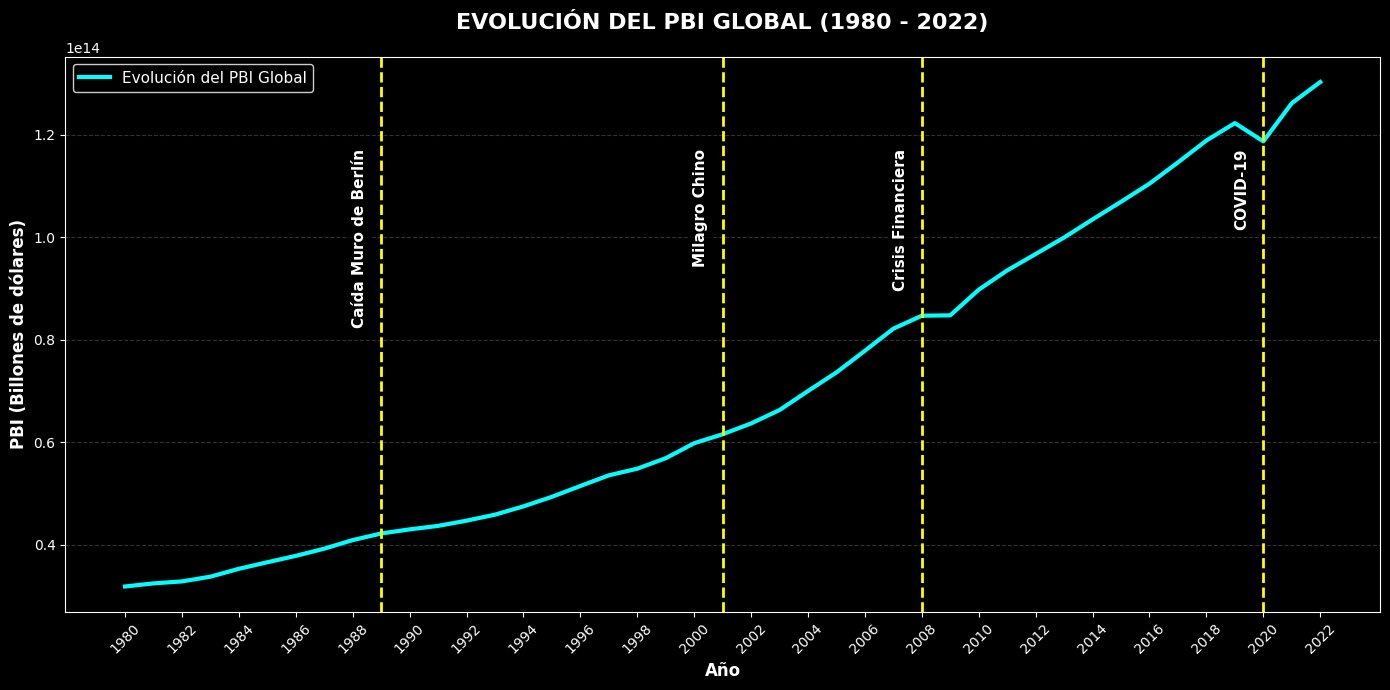

In [12]:
### CREACIÓN DEL GRÁFICO DE EVOLUCIÓN DEL PBI GLOBAL ###

import matplotlib.pyplot as plt
import pandas as pd

# 1. Limpieza y preparación de datos
df_limpio = df.dropna(subset=['gdp', 'year'])
es_1983 = df_limpio['year'] == 1983
if es_1983.any():
    min_pbi_1983 = df_limpio[es_1983]['gdp'].min()
    df_limpio = df_limpio[~((es_1983) & (df_limpio['gdp'] == min_pbi_1983))]

# 2. Groupby: Agrupamos por año
pbi_por_año = df_limpio.groupby('year')['gdp'].sum().reset_index()
año_min = int(pbi_por_año['year'].min())
año_max = int(pbi_por_año['year'].max())

# 3. Configuración del Gráfico con fondo negro
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor('black')
ax.set_facecolor('black')

# Línea del PBI en color Cian brillante para contraste
plt.plot(pbi_por_año['year'], pbi_por_año['gdp'], color='#00FFFF', linewidth=3, label='Evolución del PBI Global')

# 4. Hitos Históricos con colores vibrantes
hitos = {
    1989: 'Caída Muro de Berlín',
    2001: 'Milagro Chino',
    2008: 'Crisis Financiera',
    2020: 'COVID-19'
}

y_max = pbi_por_año['gdp'].max()

for anio, evento in hitos.items():
    # Línea vertical amarilla neón para alto contraste
    plt.axvline(x=anio, color='#FFFF00', linestyle='--', linewidth=2)

    # Texto con fondo negro y letra blanca
    plt.text(anio - 0.5, y_max * 0.90, evento,
             rotation=90, color='white', fontsize=11, fontweight='bold',
             ha='right', va='top',
             bbox=dict(facecolor='black', alpha=0.7, edgecolor='none', pad=3))

# 5. Títulos y Etiquetas
plt.title(f'EVOLUCIÓN DEL PBI GLOBAL ({año_min} - {año_max})', fontsize=16, fontweight='bold', color='white', pad=20)

plt.xlabel('Año', fontsize=12, fontweight='bold', color='white')
plt.ylabel('PBI (Billones de dólares)', fontsize=12, fontweight='bold', color='white')

plt.xticks(range(año_min, año_max + 1, 2), rotation=45, color='white')
plt.yticks(color='white')

# Grilla y leyenda
plt.grid(axis='y', linestyle='--', alpha=0.2)
plt.legend(loc='upper left', fontsize=11, facecolor='black', edgecolor='white')
plt.tight_layout()

plt.show()
plt.style.use('default')

In [13]:
### CLASIFICACIÓN GEOGRÁFICA DE LOS PAÍSES ###

# AMÉRICA
america_del_sur = ['Argentina', 'Bolivia', 'Brazil', 'Chile', 'Colombia', 'Ecuador', 'Guyana', 'Paraguay', 'Peru', 'Suriname', 'Uruguay', 'Venezuela']
america_central_y_caribe = ['Belize', 'Costa Rica', 'El Salvador', 'Guatemala', 'Honduras','Nicaragua', 'Panama', 'Bahamas', 'Barbados', 'Cuba', 'Dominica','Dominican Republic', 'Grenada', 'Haiti', 'Jamaica', 'Saint Kitts and Nevis','Saint Lucia', 'Saint Vincent and the Grenadines', 'Trinidad and Tobago']
america_del_norte = ['Canada', 'United States', 'Mexico']

# EUROPA
europa = ['Albania', 'Andorra', 'Austria', 'Belarus', 'Belgium', 'Bosnia and Herzegovina','Bulgaria', 'Croatia', 'Cyprus', 'Czechia', 'Denmark', 'Estonia', 'Finland','France', 'Germany', 'Greece', 'Hungary', 'Iceland', 'Ireland', 'Italy','Latvia', 'Lithuania', 'Luxembourg', 'Malta', 'Moldova', 'Montenegro','Netherlands', 'North Macedonia', 'Norway', 'Poland', 'Portugal', 'Romania','Russia', 'Serbia', 'Slovakia', 'Slovenia', 'Spain', 'Sweden', 'Switzerland','Ukraine', 'United Kingdom']

# ÁFRICA
africa = ['Algeria', 'Angola', 'Benin', 'Botswana', 'Burkina Faso', 'Burundi', 'Cabo Verde','Cameroon', 'Central African Republic', 'Chad', 'Comoros', 'Congo', 'Cote d\'Ivoire','Democratic Republic of Congo', 'Djibouti', 'Egypt', 'Equatorial Guinea', 'Eritrea','Eswatini', 'Ethiopia', 'Gabon', 'Gambia', 'Ghana', 'Guinea', 'Guinea-Bissau','Kenya', 'Lesotho', 'Liberia', 'Libya', 'Madagascar', 'Malawi', 'Mali','Mauritania', 'Mauritius', 'Morocco', 'Mozambique', 'Namibia', 'Niger','Nigeria', 'Rwanda', 'Sao Tome and Principe', 'Senegal', 'Seychelles','Sierra Leone', 'Somalia', 'South Africa', 'South Sudan', 'Sudan', 'Tanzania','Togo', 'Tunisia', 'Uganda', 'Zambia', 'Zimbabwe']

# ASIA
asia = ['Afghanistan', 'Armenia', 'Azerbaijan', 'Bahrain', 'Bangladesh', 'Bhutan','Brunei', 'Cambodia', 'China', 'Georgia', 'India', 'Indonesia', 'Iran','Iraq', 'Israel', 'Japan', 'Jordan', 'Kazakhstan', 'Kuwait', 'Kyrgyzstan','Laos', 'Lebanon', 'Malaysia', 'Maldives', 'Mongolia', 'Myanmar', 'Nepal','North Korea', 'Oman', 'Pakistan', 'Palestine', 'Philippines', 'Qatar','Saudi Arabia', 'Singapore', 'South Korea', 'Sri Lanka', 'Syria', 'Taiwan','Tajikistan', 'Thailand', 'Timor', 'Turkey', 'Turkmenistan','United Arab Emirates', 'Uzbekistan', 'Vietnam', 'Yemen']

# OCEANÍA
oceania = ['Australia', 'Fiji', 'Kiribati', 'Marshall Islands', 'Micronesia (country)','Nauru', 'New Zealand', 'Palau', 'Papua New Guinea', 'Samoa','Solomon Islands', 'Tonga', 'Tuvalu', 'Vanuatu']

# CREAMOS UN DF ESPECIALMENTE PARA ARGENTINA
df_argentina = df[df['country'] == 'Argentina']

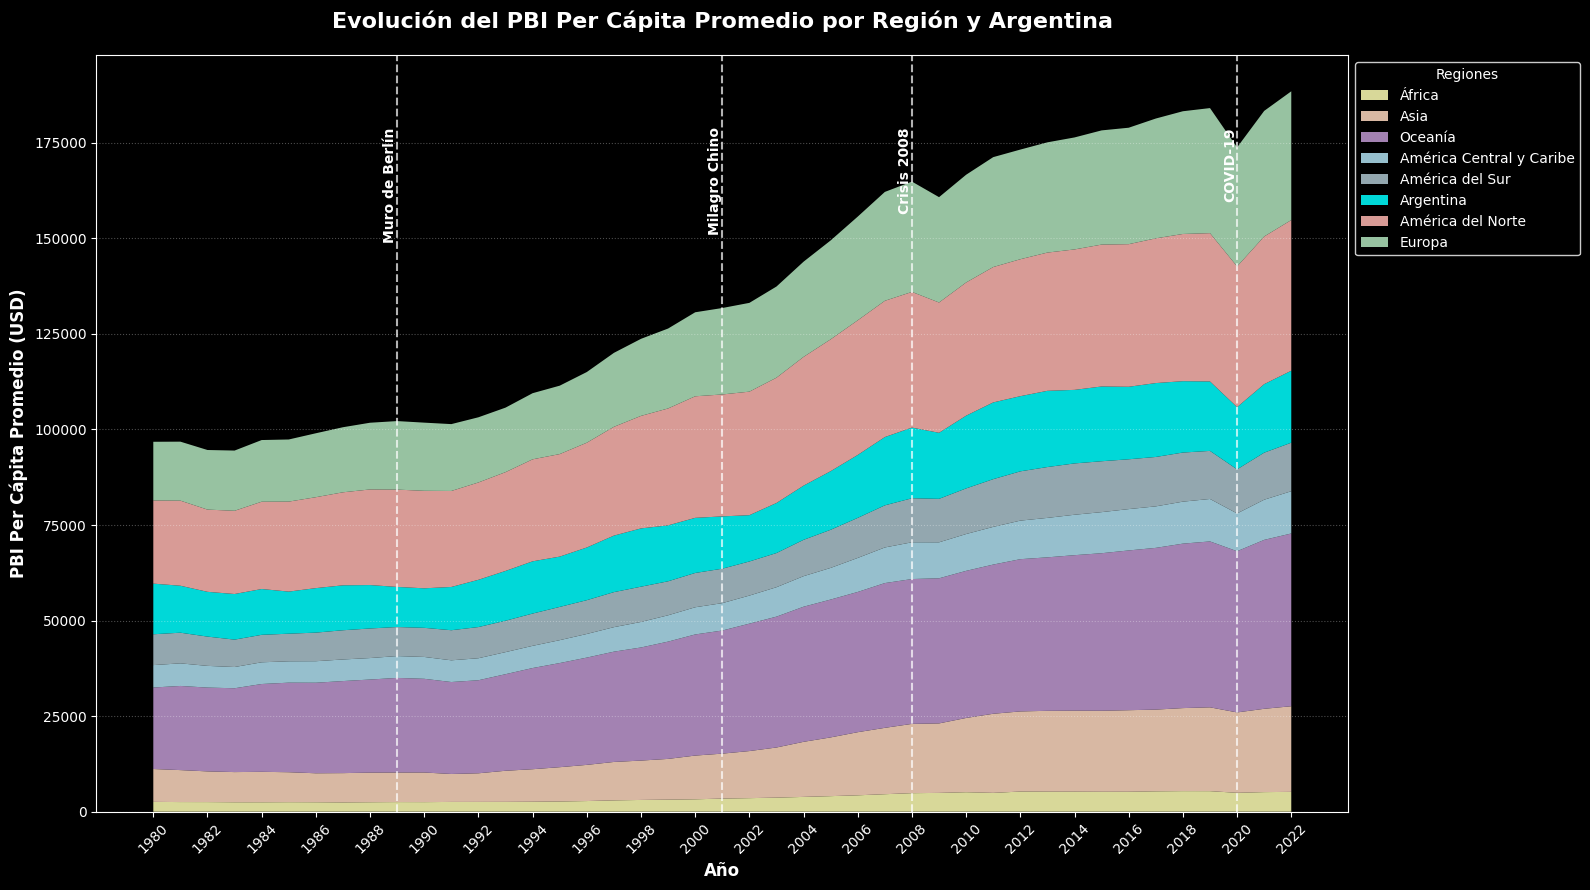

In [14]:
### CREACIÓN GRÁFICO ÁREAS APILADAS ###

import matplotlib.pyplot as plt
import pandas as pd

# 1. Definir función para asignar región
def asignar_region(country):
    if country == 'Argentina': return 'Argentina'
    if country in america_del_sur: return 'América del Sur'
    if country in america_del_norte: return 'América del Norte'
    if country in america_central_y_caribe: return 'América Central y Caribe'
    if country in europa: return 'Europa'
    if country in africa: return 'África'
    if country in asia: return 'Asia'
    if country in oceania: return 'Oceanía'
    return 'Otros'

# 2. Preparar el DataFrame
df_regiones = df.copy()
df_regiones['region'] = df_regiones['country'].apply(asignar_region)

# Filtrar 'Otros' y años sin PBI per cápita
df_regiones = df_regiones[(df_regiones['region'] != 'Otros') & (df_regiones['gdp_per_capita'].notna())]

# 3. Pivotar los datos: Promedio de PBI per cápita por región y año
evolucion_pbi = df_regiones.pivot_table(
    index='year',
    columns='region',
    values='gdp_per_capita',
    aggfunc='mean'
).fillna(0)

# 4. Ordenar las columnas para el stack
orden_regiones = ['África', 'Asia', 'Oceanía', 'América Central y Caribe', 'América del Sur', 'Argentina', 'América del Norte', 'Europa']
evolucion_pbi = evolucion_pbi[[col for col in orden_regiones if col in evolucion_pbi.columns]]

# 5. Colores y Hitos
paleta = {
    'América del Sur': '#AEC6CF', 'América del Norte': '#FFB7B2',
    'América Central y Caribe': '#B2E2F2', 'Europa': '#B3E5BE',
    'Asia': '#FFDAC1', 'África': '#FFFFB5', 'Oceanía': '#C19AD3',
    'Argentina': '#00FFFF' # Cyan brillante para resaltar en negro
}
colores = [paleta.get(reg, '#CCCCCC') for reg in evolucion_pbi.columns]

hitos = {
    1989: 'Muro de Berlín',
    2001: 'Milagro Chino',
    2008: 'Crisis 2008',
    2020: 'COVID-19'
}

# 6. Creación del Gráfico
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(16, 9))
fig.patch.set_facecolor('black')
ax.set_facecolor('black')

plt.stackplot(evolucion_pbi.index, evolucion_pbi.T, labels=evolucion_pbi.columns, colors=colores, alpha=0.85)

# Agregar líneas de hitos históricos
y_max_total = evolucion_pbi.sum(axis=1).max()
for anio, evento in hitos.items():
    plt.axvline(x=anio, color='white', linestyle='--', linewidth=1.5, alpha=0.7)
    plt.text(anio, y_max_total * 0.95, evento, rotation=90, verticalalignment='top',
             horizontalalignment='right', fontsize=10, fontweight='bold', color='white')

plt.title('Evolución del PBI Per Cápita Promedio por Región y Argentina', fontsize=16, fontweight='bold', pad=20, color='white')
plt.xlabel('Año', fontsize=12, fontweight='bold', color='white')
plt.ylabel('PBI Per Cápita Promedio (USD)', fontsize=12, fontweight='bold', color='white')

# Configurar más años en el eje X (cada 2 años)
anio_min = int(evolucion_pbi.index.min())
anio_max = int(evolucion_pbi.index.max())
plt.xticks(range(anio_min, anio_max + 1, 2), rotation=45, color='white')
plt.yticks(color='white')

plt.legend(loc='upper left', bbox_to_anchor=(1, 1), title='Regiones', facecolor='black', edgecolor='white')
plt.grid(axis='y', linestyle=':', alpha=0.3)
plt.tight_layout()

plt.show()
plt.style.use('default')

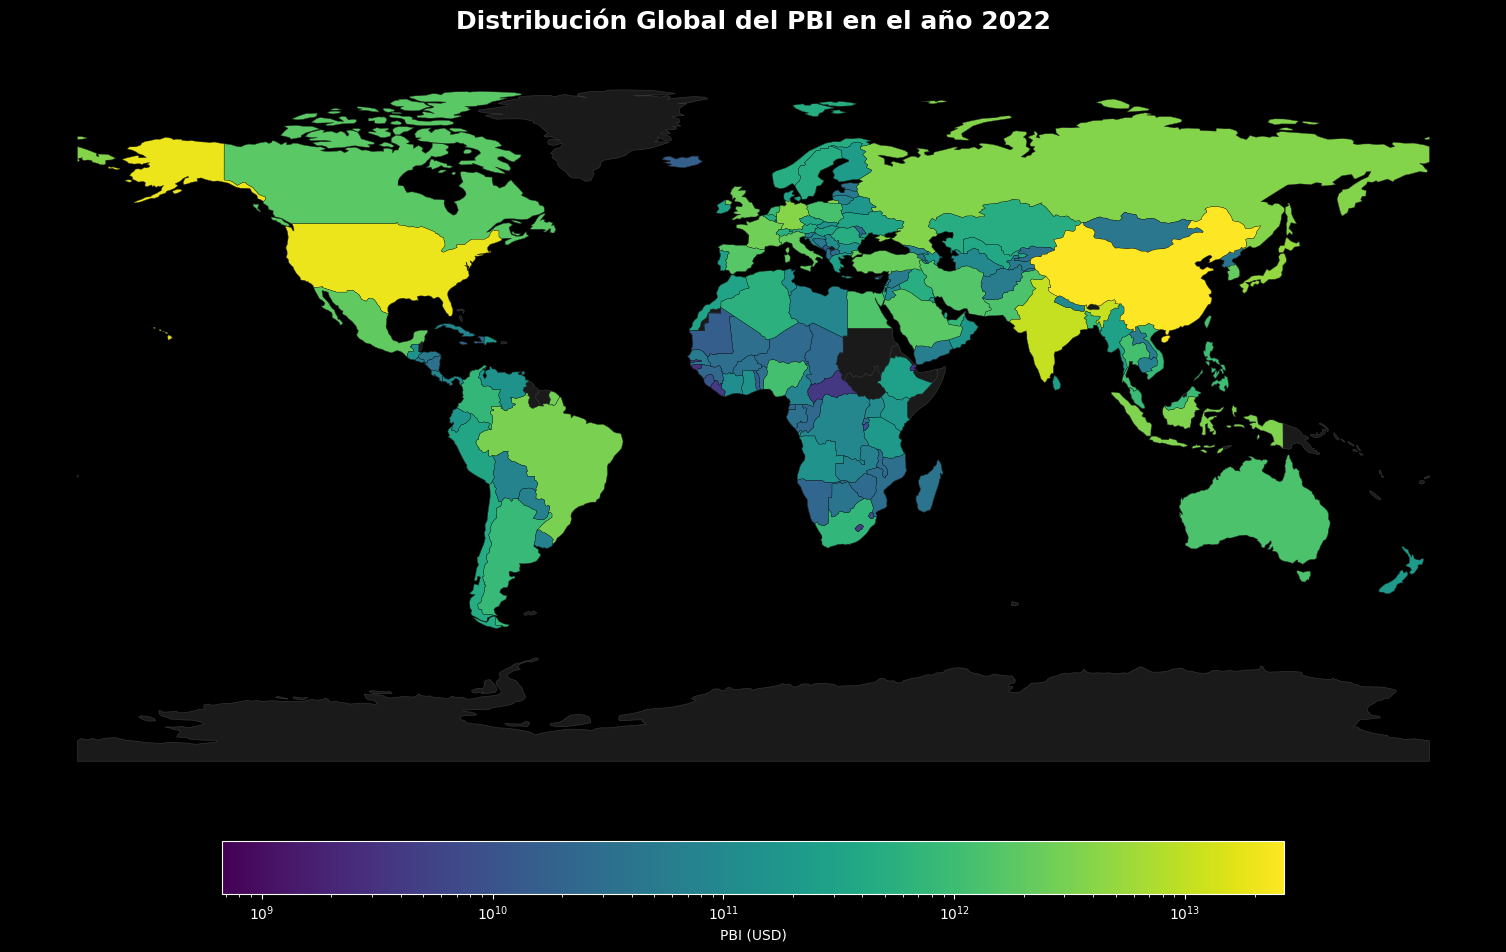

In [48]:
### MAPA DE CALOR: PBI GLOBAL A 2022 ###

import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.colors as colors

try:
    import geopandas as gpd
except ImportError:
    !pip install geopandas
    import geopandas as gpd

# 1. Obtener el último año con datos de PBI
ultimo_año = df.dropna(subset=['gdp'])['year'].max()
df_ultimo = df[df['year'] == ultimo_año].copy()

# 2. Cargar mapa mundial
path_mapa = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(path_mapa)

# 3. Unir datos
world = world.merge(df_ultimo, left_on='ADM0_A3', right_on='iso_code', how='left')

# 4. Crear el gráfico con fondo negro
plt.style.use('dark_background')
fig, ax = plt.subplots(1, 1, figsize=(18, 10))
fig.patch.set_facecolor('black')
ax.set_facecolor('black')

# Fondo para países sin datos (Gris muy oscuro)
world.plot(ax=ax, color='#1a1a1a', edgecolor='#333333', linewidth=0.5)

# Mapa de calor con escala viridis (monocromática de oscuro a brillante para contraste)
sm = world.dropna(subset=['gdp']).plot(
    column='gdp',
    ax=ax,
    legend=True,
    cmap='viridis',
    norm=colors.LogNorm(vmin=df_ultimo['gdp'].min(), vmax=df_ultimo['gdp'].max()),
    legend_kwds={
        'label': "PBI (USD)",
        'orientation': "horizontal",
        'pad': 0.05,
        'shrink': 0.6
    },
    edgecolor='black',
    linewidth=0.2
)

plt.title(f'Distribución Global del PBI en el año {int(ultimo_año)}', fontsize=18, fontweight='bold', color='white', pad=20)
ax.set_axis_off()

plt.tight_layout()
plt.show()
plt.style.use('default')

In [16]:
# Creamos DataFrame para Caída Muro Berlín (1984-1994)
df_muro_berlin = df[(df['year'] >= 1984) & (df['year'] <= 1994)]
# Creamos DataFrame para Milagro Chino (1996-2006)
df_milagro_chino = df[(df['year'] >= 1996) & (df['year'] <= 2006)]
# Creamos DataFrame Crisis Financiera (2003-2013)
df_crisis_financiera = df[(df['year'] >= 2003) & (df['year'] <= 2013)]
# Creamos DataFrame COVID-19 (2014-2022)
df_covid_19 = df[(df['year'] >= 2014) & (df['year'] <= 2022)]

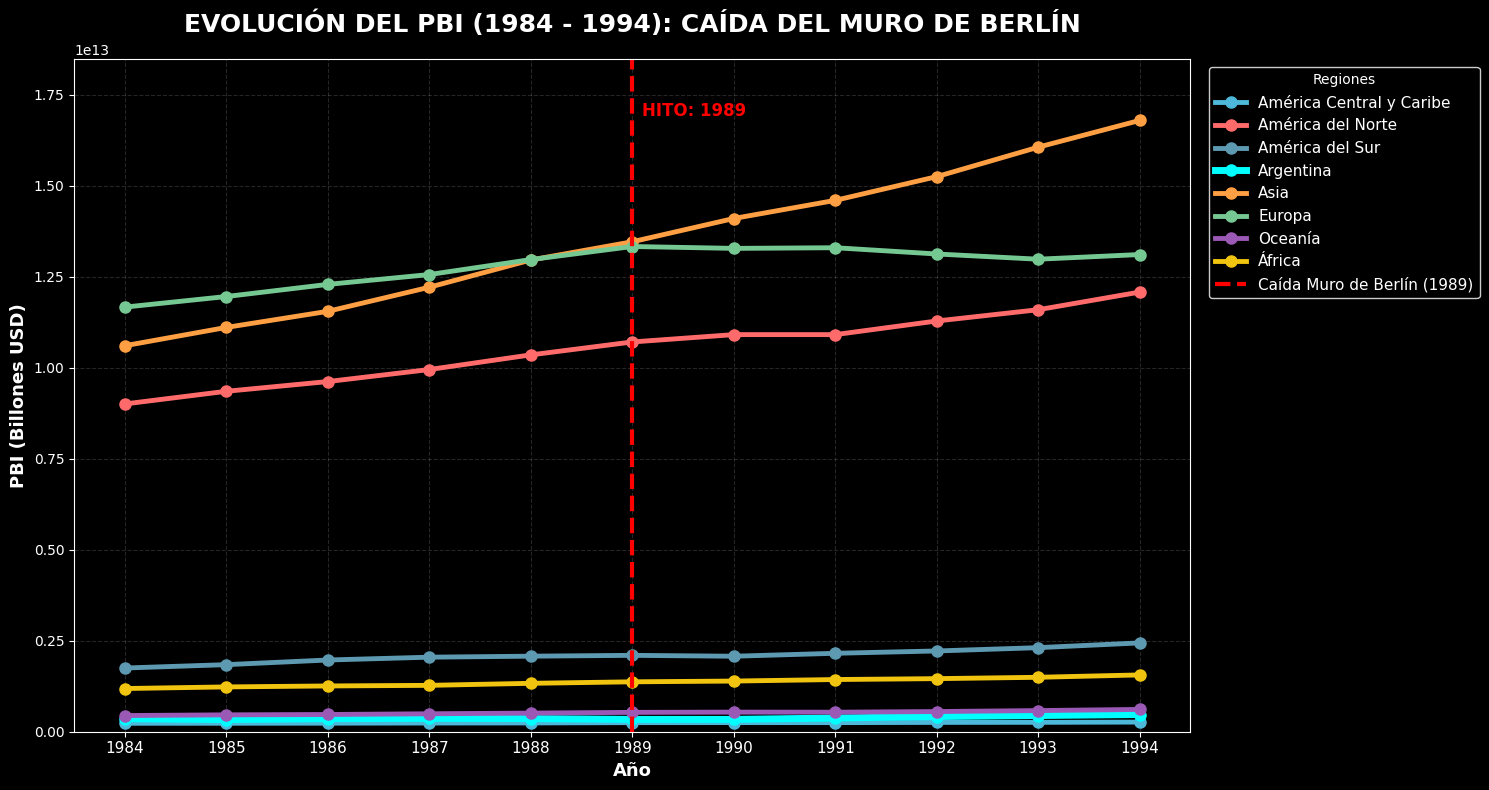

In [17]:
### EVOLUCIÓN DEL PBI: CAÍDA DEL MURO DE BERLÍN (1984-1994) ###

import matplotlib.pyplot as plt

# 1. Configurar estilo de contraste (fondo oscuro)
plt.style.use('dark_background')

# 2. Definir la paleta con la MISMA GAMA pero COLORES MÁS FUERTES
paleta = {
    'América del Sur': '#5D99B0',       # Azul más fuerte
    'América del Norte': '#FF6B6B',     # Salmón/Rojo más fuerte
    'América Central y Caribe': '#4DB8D9', # Celeste más profundo
    'Europa': '#76C893',               # Verde más intenso
    'Asia': '#FF9F43',                 # Durazno/Naranja más vivo
    'África': '#F1C40F',               # Amarillo más sólido
    'Oceanía': '#9B59B6',              # Lavanda/Púrpura más oscuro
    'Argentina': '#00FFFF'             # Cyan brillante para resaltar en negro
}

# 3. Preparar los datos
df_periodo = df_muro_berlin.copy()
df_periodo['region'] = df_periodo['country'].apply(asignar_region)
evolucion_regiones = df_periodo[df_periodo['region'] != 'Otros'].groupby(['year', 'region'])['gdp'].sum().unstack()

# 4. Graficar
fig, ax = plt.subplots(figsize=(15, 8))
fig.patch.set_facecolor('black')
ax.set_facecolor('black')

# Dibujar líneas de regiones y Argentina con los colores intensificados
for region in evolucion_regiones.columns:
    color = paleta.get(region, '#CCCCCC')
    linewidth = 5 if region == 'Argentina' else 3.5
    plt.plot(evolucion_regiones.index, evolucion_regiones[region], marker='o', markersize=8, color=color, linewidth=linewidth, label=region)

# 5. Hito Histórico: Línea roja vertical para contraste
plt.axvline(x=1989, color='#FF0000', linestyle='--', linewidth=3, label='Caída Muro de Berlín (1989)')
plt.text(1989.1, evolucion_regiones.max().max(), 'HITO: 1989', color='#FF0000', fontsize=12, fontweight='bold', verticalalignment='bottom')

# 6. Configuración estética
max_region = evolucion_regiones.max().max()
plt.ylim(0, max_region * 1.1)

plt.title('EVOLUCIÓN DEL PBI (1984 - 1994): CAÍDA DEL MURO DE BERLÍN', fontsize=18, fontweight='bold', color='white', pad=20)
plt.xlabel('Año', fontsize=13, fontweight='bold')
plt.ylabel('PBI (Billones USD)', fontsize=13, fontweight='bold')

plt.xticks(range(1984, 1995), fontsize=11)
plt.grid(True, linestyle='--', alpha=0.15)
plt.legend(title="Regiones", bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=11, facecolor='black', edgecolor='white')

plt.tight_layout()
plt.show()

# Restauramos estilo por defecto
plt.style.use('default')

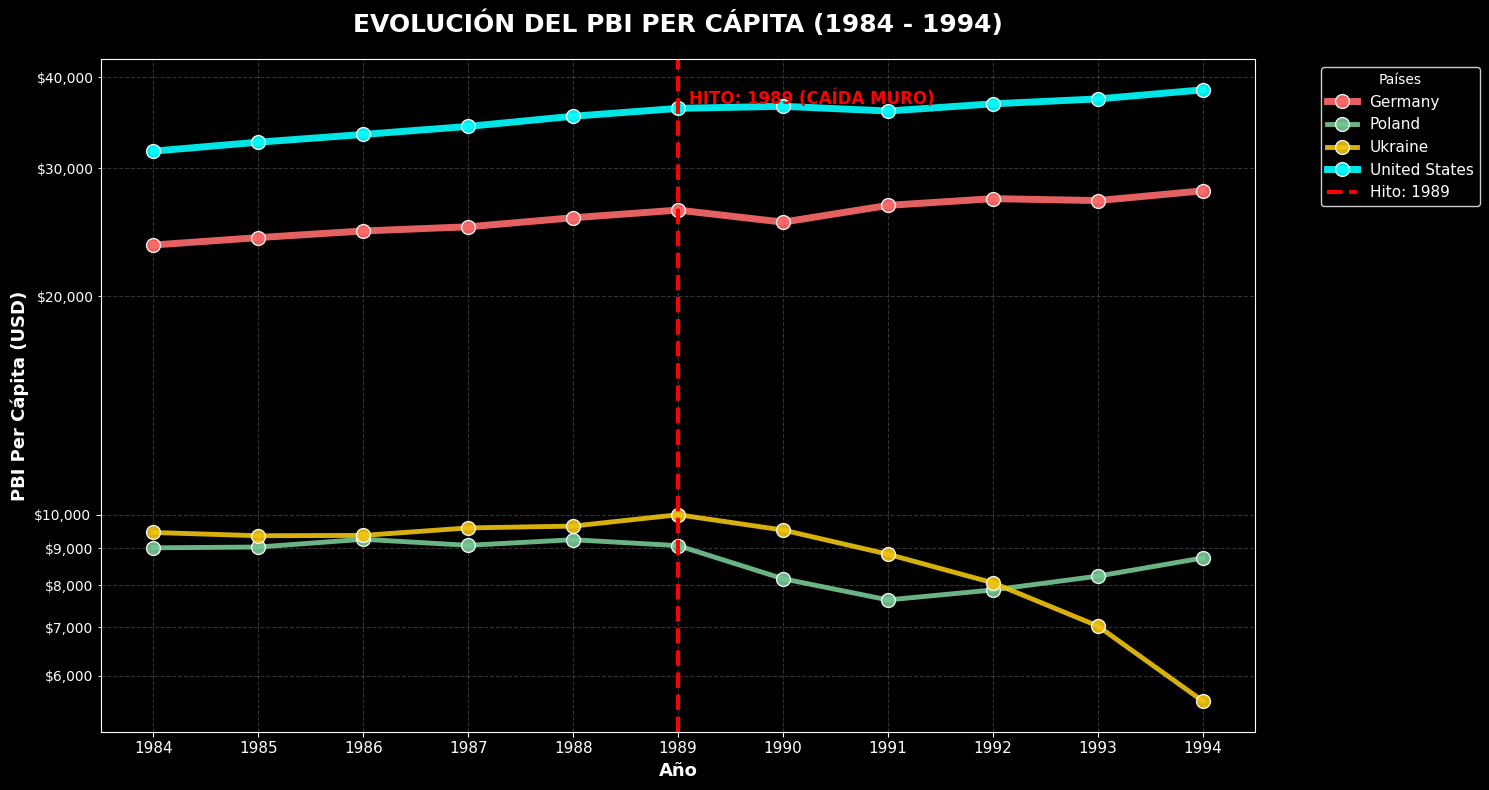

In [56]:
### COMPARATIVA PBI PER CÁPITA: EUROPA DEL ESTE, ALEMANIA Y EEUU (1984-1994) ###

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# 1. Configurar estilo de contraste
plt.style.use('dark_background')

# 2. Definir países y colores específicos
paises_comp = ['Germany', 'United States', 'Poland', 'Ukraine']
colores_paises = {
    'United States': '#00FFFF',   # Cyan brillante
    'Germany': '#FF6B6B',         # Salmón
    'Poland': '#76C893',          # Verde
    'Ukraine': '#F1C40F'          # Amarillo
}

# 3. Preparar los datos (Rango 1984-1994) - USAMOS PBI PER CÁPITA
df_comp_custom = df[(df['country'].isin(paises_comp)) & (df['year'] >= 1984) & (df['year'] <= 1994)]
evolucion_custom = df_comp_custom.pivot_table(index='year', columns='country', values='gdp_per_capita')

# 4. Graficar
fig, ax = plt.subplots(figsize=(15, 8))
fig.patch.set_facecolor('black')
ax.set_facecolor('black')

# Usamos escala logarítmica para ver mejor los quiebres proporcionales
ax.set_yscale('log')

for pais in evolucion_custom.columns:
    color = colores_paises.get(pais, '#CCCCCC')
    linewidth = 5 if pais in ['United States', 'Germany'] else 3.5
    plt.plot(evolucion_custom.index, evolucion_custom[pais],
             marker='o', markersize=10, markeredgecolor='white',
             color=color, linewidth=linewidth, label=pais, alpha=0.9)

# 5. Hito Histórico: Caída del Muro de Berlín (1989)
plt.axvline(x=1989, color='#FF0000', linestyle='--', linewidth=3, label='Hito: 1989')
plt.text(1989.1, evolucion_custom.max().max(), 'HITO: 1989 (CAÍDA MURO)',
         color='#FF0000', fontsize=12, fontweight='bold', verticalalignment='top')

# 6. Configuración estética
plt.title('EVOLUCIÓN DEL PBI PER CÁPITA (1984 - 1994)',
          fontsize=18, fontweight='bold', color='white', pad=20)
plt.xlabel('Año', fontsize=13, fontweight='bold')
plt.ylabel('PBI Per Cápita (USD)', fontsize=13, fontweight='bold')

# Mejora de la escala: Formateo de moneda
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'${x:,.0f}'))
ax.yaxis.set_minor_formatter(ticker.FuncFormatter(lambda x, pos: f'${x:,.0f}' if x >= 1000 else ''))

plt.xticks(range(1984, 1995), fontsize=11)
plt.grid(True, which='both', linestyle='--', alpha=0.2)

# AJUSTE DE LEYENDA: Fuera del área de trazado para evitar superposiciones
plt.legend(title="Países", bbox_to_anchor=(1.05, 1), loc='upper left',
           fontsize=11, facecolor='black', edgecolor='white')

plt.tight_layout()
plt.show()

# Restaurar estilo
plt.style.use('default')

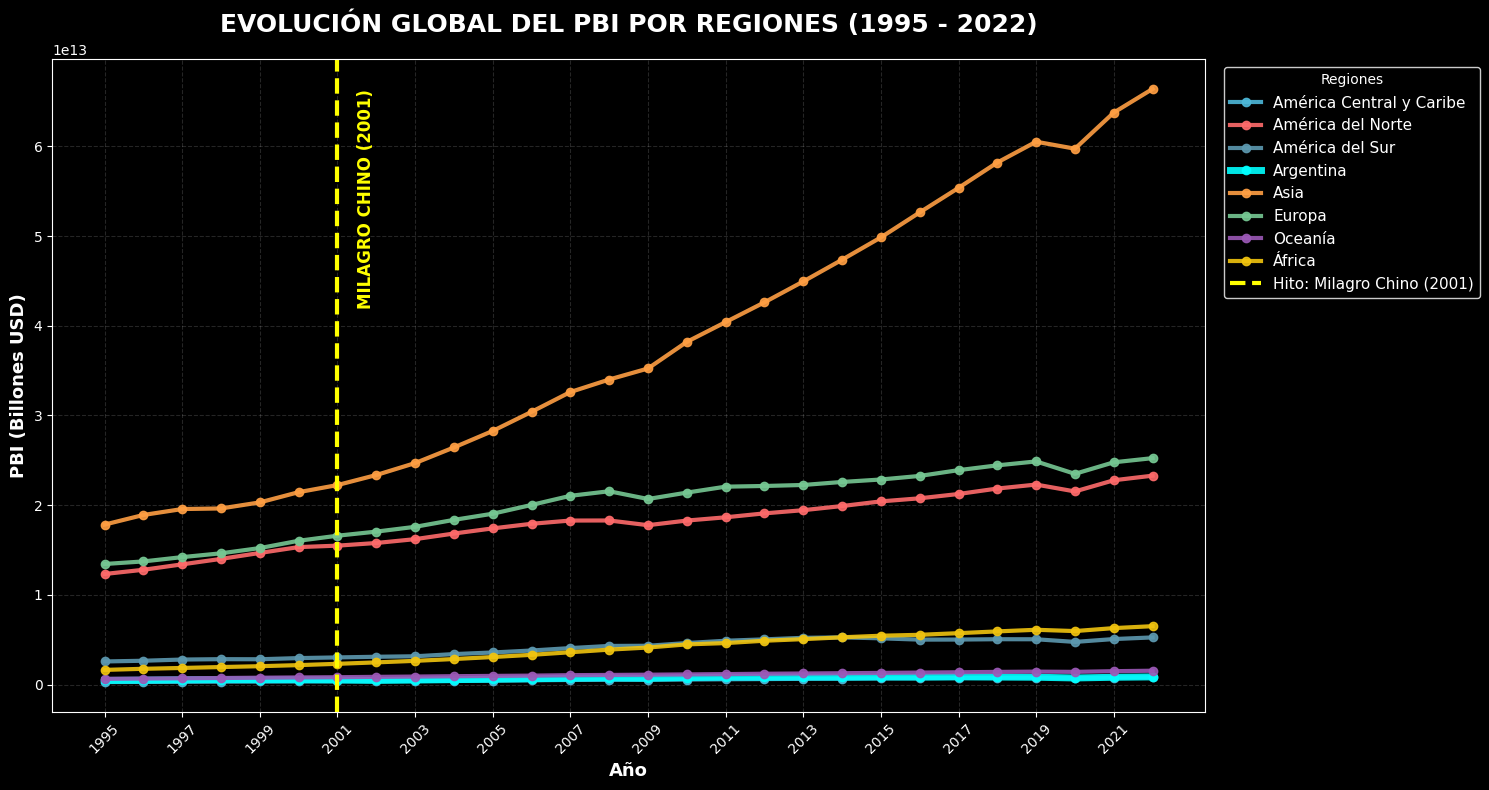

In [18]:
### EVOLUCIÓN DEL PBI POR REGIONES: MILAGRO CHINO ###

import matplotlib.pyplot as plt

# 1. Configurar estilo de contraste
plt.style.use('dark_background')

# 2. Definir paleta de colores vibrantes establecida
paleta = {
    'América del Sur': '#5D99B0',
    'América del Norte': '#FF6B6B',
    'América Central y Caribe': '#4DB8D9',
    'Europa': '#76C893',
    'Asia': '#FF9F43',
    'África': '#F1C40F',
    'Oceanía': '#9B59B6',
    'Argentina': '#00FFFF'
}

# 3. Preparar los datos (Rango 1995-2022)
anio_inicio = 1995
anio_fin = 2022

df_periodo = df[(df['year'] >= anio_inicio) & (df['year'] <= anio_fin)].copy()
df_periodo['region'] = df_periodo['country'].apply(asignar_region)

# Agrupamos por año y región para sumar el PBI
evolucion_regiones = df_periodo[df_periodo['region'] != 'Otros'].groupby(['year', 'region'])['gdp'].sum().unstack()

# 4. Graficar
fig, ax = plt.subplots(figsize=(15, 8))
fig.patch.set_facecolor('black')
ax.set_facecolor('black')

for region in evolucion_regiones.columns:
    color = paleta.get(region, '#CCCCCC')
    linewidth = 5 if region == 'Argentina' else 3
    plt.plot(evolucion_regiones.index, evolucion_regiones[region],
             marker='o', markersize=6, color=color, linewidth=linewidth, label=region, alpha=0.9)

# 5. Hito Histórico: Milagro Chino (2001)
max_val = evolucion_regiones.max().max()
plt.axvline(x=2001, color='#FFFF00', linestyle='--', linewidth=3, label='Hito: Milagro Chino (2001)')
plt.text(2001.5, max_val, 'MILAGRO CHINO (2001)', color='#FFFF00',
         fontsize=12, fontweight='bold', rotation=90, verticalalignment='top')

# 6. Configuración estética
plt.title(f'EVOLUCIÓN GLOBAL DEL PBI POR REGIONES ({anio_inicio} - {anio_fin})', fontsize=18, fontweight='bold', color='white', pad=20)
plt.xlabel('Año', fontsize=13, fontweight='bold')
plt.ylabel('PBI (Billones USD)', fontsize=13, fontweight='bold')

plt.xticks(range(anio_inicio, anio_fin + 1, 2), rotation=45, fontsize=10)
plt.grid(True, linestyle='--', alpha=0.15)
plt.legend(title="Regiones", bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=11, facecolor='black', edgecolor='white')

plt.tight_layout()
plt.show()

# Restaurar estilo
plt.style.use('default')

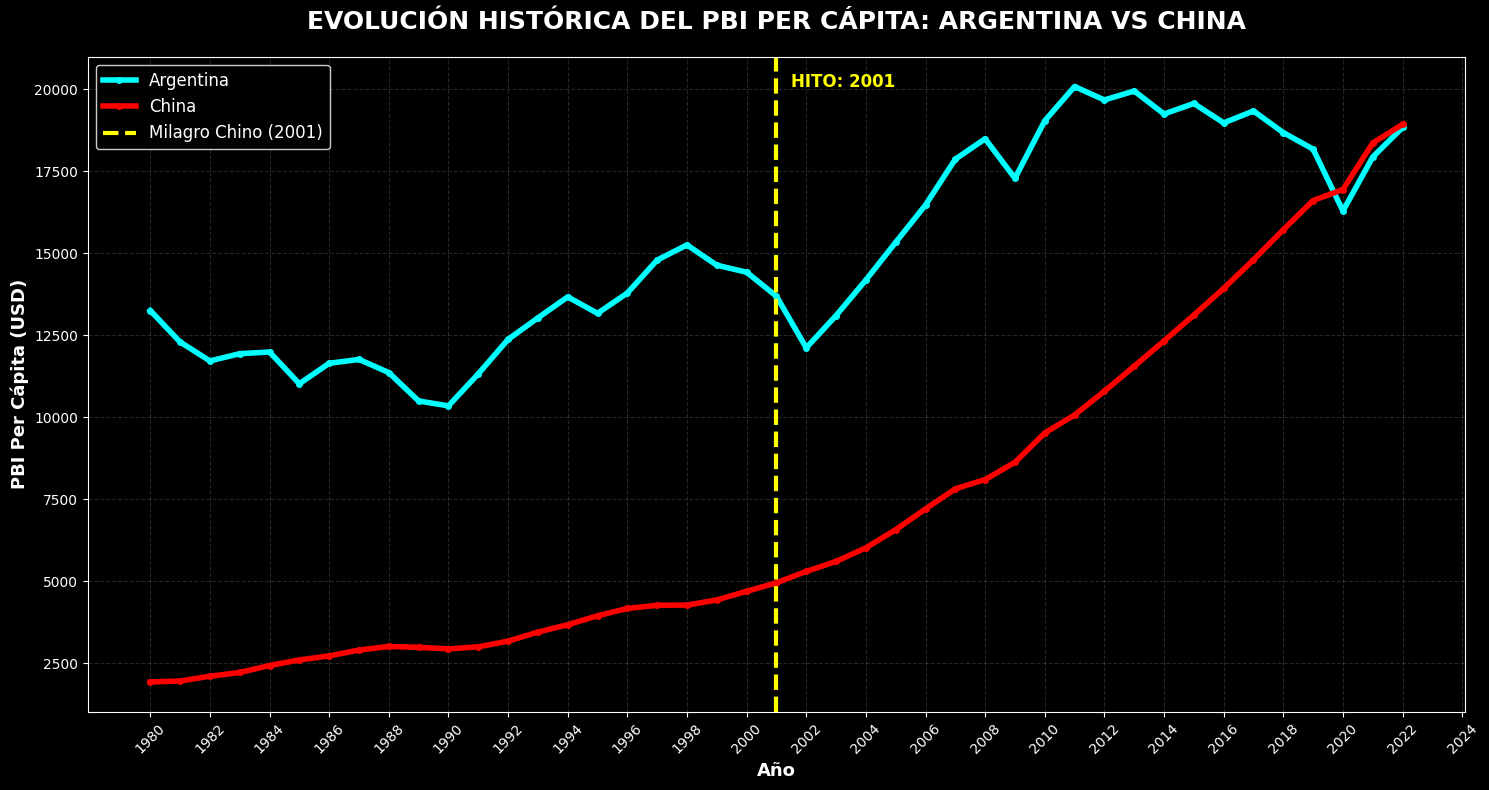

In [39]:
### EVOLUCIÓN DEL PBI PER CÁPITA: ARGENTINA Y CHINA ###
import matplotlib.pyplot as plt

# 1. Configurar estilo de contraste
plt.style.use('dark_background')

# 2. Preparar los datos
evolucion_arg = df[df['country'] == 'Argentina']
evolucion_china = df[df['country'] == 'China']

# 3. Graficar
fig, ax = plt.subplots(figsize=(15, 8))
fig.patch.set_facecolor('black')
ax.set_facecolor('black')

plt.plot(evolucion_arg['year'], evolucion_arg['gdp_per_capita'], color='#00FFFF', linewidth=4, label='Argentina', marker='o', markersize=4)
plt.plot(evolucion_china['year'], evolucion_china['gdp_per_capita'], color='red', linewidth=4, label='China', marker='o', markersize=4)

# 4. Hito Histórico
plt.axvline(x=2001, color='#FFFF00', linestyle='--', linewidth=3, label='Milagro Chino (2001)')
plt.text(2001.5, max(evolucion_arg['gdp_per_capita'].max(), evolucion_china['gdp_per_capita'].max()), 'HITO: 2001',
         color='#FFFF00', fontsize=12, fontweight='bold')

# 5. Configuración estética y X-axis
plt.title('EVOLUCIÓN HISTÓRICA DEL PBI PER CÁPITA: ARGENTINA VS CHINA', color='white', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Año', fontsize=13, fontweight='bold')
plt.ylabel('PBI Per Cápita (USD)', fontsize=13, fontweight='bold')

# Ajuste de ticks para no saltar tantos años (cada 2 años)
anio_min = int(df['year'].min())
anio_max = int(df['year'].max())
plt.xticks(range(anio_min, anio_max + 1, 2), rotation=45, fontsize=10)

plt.grid(True, linestyle='--', alpha=0.15)
plt.legend(loc='upper left', fontsize=12, facecolor='black', edgecolor='white')

plt.tight_layout()
plt.show()

# Restaurar estilo
plt.style.use('default')

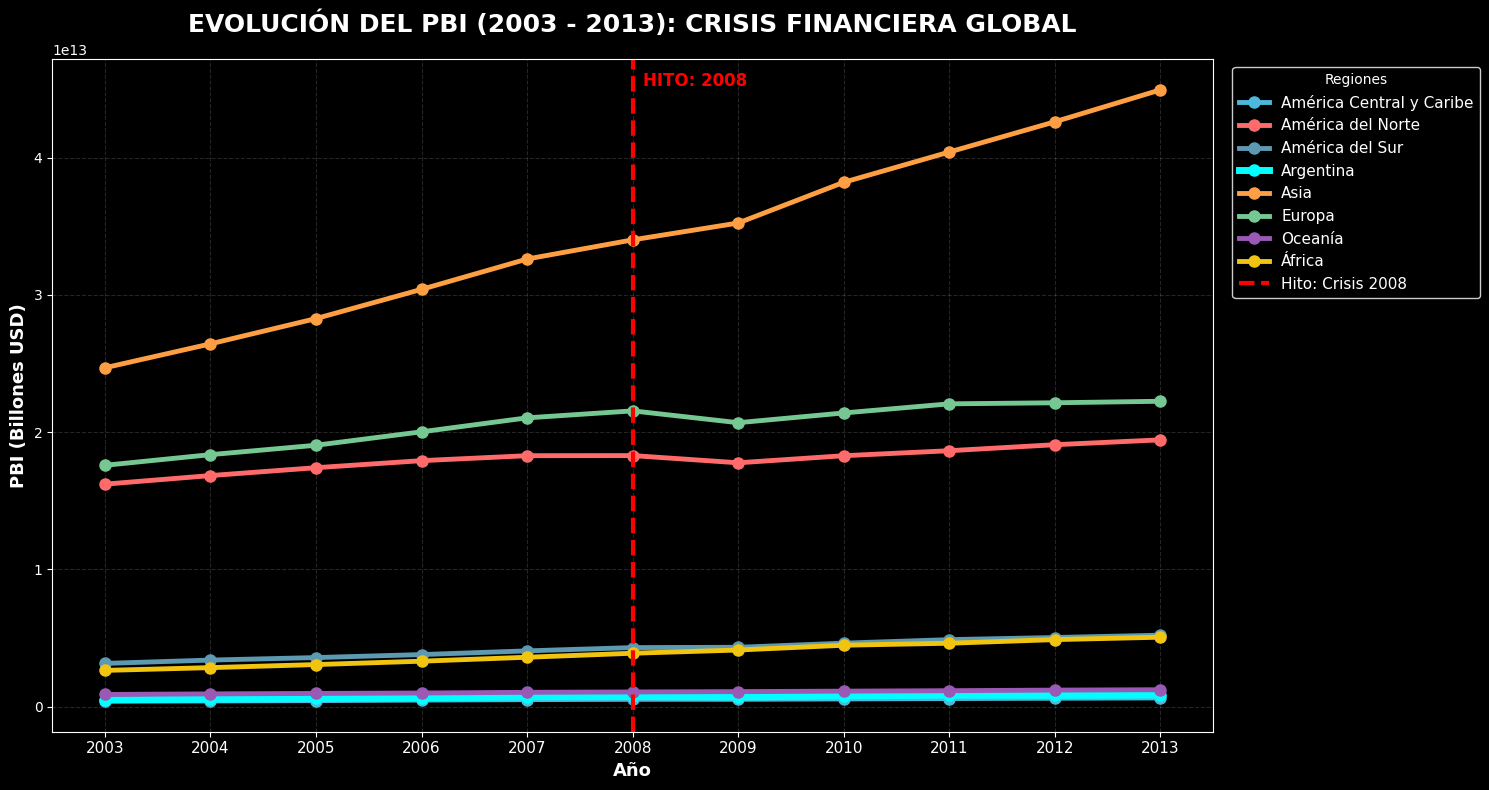

In [37]:
### EVOLUCIÓN DEL PBI: CRISIS FINANCIERA (2003-2013) ###
import matplotlib.pyplot as plt

# 1. Configurar estilo de contraste
plt.style.use('dark_background')

# 2. Definir la paleta con los COLORES FUERTES establecidos
paleta = {
    'América del Sur': '#5D99B0',
    'América del Norte': '#FF6B6B',
    'América Central y Caribe': '#4DB8D9',
    'Europa': '#76C893',
    'Asia': '#FF9F43',
    'África': '#F1C40F',
    'Oceanía': '#9B59B6',
    'Argentina': '#00FFFF'
}

# 3. Preparar los datos del período
df_periodo = df_crisis_financiera.copy()
df_periodo['region'] = df_periodo['country'].apply(asignar_region)
evolucion_regiones = df_periodo[df_periodo['region'] != 'Otros'].groupby(['year', 'region'])['gdp'].sum().unstack()

# 4. Graficar
fig, ax = plt.subplots(figsize=(15, 8))
fig.patch.set_facecolor('black')
ax.set_facecolor('black')

for region in evolucion_regiones.columns:
    color = paleta.get(region, '#CCCCCC')
    linewidth = 5 if region == 'Argentina' else 3.5
    plt.plot(evolucion_regiones.index, evolucion_regiones[region], marker='o', markersize=8, color=color, linewidth=linewidth, label=region)

# 5. Hito Histórico: Crisis Financiera Global (2008)
plt.axvline(x=2008, color='#FF0000', linestyle='--', linewidth=3, label='Hito: Crisis 2008')
plt.text(2008.1, evolucion_regiones.max().max(), 'HITO: 2008', color='#FF0000', fontsize=12, fontweight='bold', verticalalignment='bottom')

# 6. Configuración estética
plt.title('EVOLUCIÓN DEL PBI (2003 - 2013): CRISIS FINANCIERA GLOBAL', fontsize=18, fontweight='bold', color='white', pad=20)
plt.xlabel('Año', fontsize=13, fontweight='bold')
plt.ylabel('PBI (Billones USD)', fontsize=13, fontweight='bold')

plt.xticks(range(2003, 2014), fontsize=11)
plt.grid(True, linestyle='--', alpha=0.15)
plt.legend(title="Regiones", bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=11, facecolor='black', edgecolor='white')

plt.tight_layout()
plt.show()

# Restaurar estilo
plt.style.use('default')

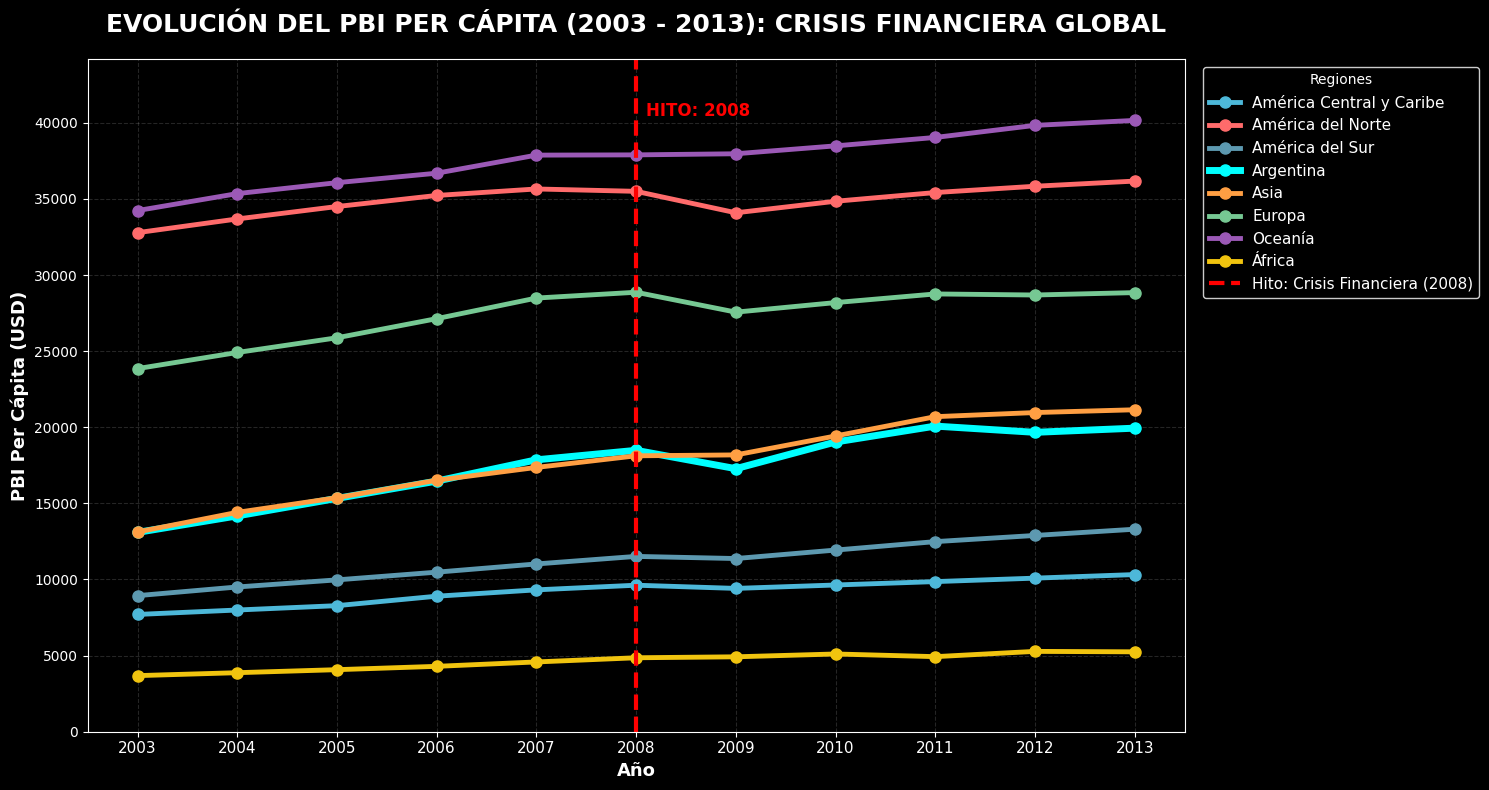

In [21]:
### EVOLUCIÓN DEL PBI PER CÁPITA: CRISIS FINANCIERA (2003-2013) ###

import matplotlib.pyplot as plt

# 1. Configurar estilo de contraste
plt.style.use('dark_background')

# 2. Definir la paleta con los COLORES FUERTES establecidos
paleta = {
    'América del Sur': '#5D99B0',       # Azul fuerte
    'América del Norte': '#FF6B6B',     # Salmón/Rojo fuerte
    'América Central y Caribe': '#4DB8D9', # Celeste profundo
    'Europa': '#76C893',               # Verde intenso
    'Asia': '#FF9F43',                 # Naranja vivo
    'África': '#F1C40F',               # Amarillo sólido
    'Oceanía': '#9B59B6',              # Púrpura oscuro
    'Argentina': '#00FFFF'             # Cyan brillante
}

# 3. Preparar los datos del período (PBI PER CÁPITA)
df_periodo = df_crisis_financiera.copy()
df_periodo['region'] = df_periodo['country'].apply(asignar_region)
# Usamos el promedio (mean) del PBI per cápita por región
evolucion_regiones = df_periodo[df_periodo['region'] != 'Otros'].groupby(['year', 'region'])['gdp_per_capita'].mean().unstack()

# 4. Graficar
fig, ax = plt.subplots(figsize=(15, 8))
fig.patch.set_facecolor('black')
ax.set_facecolor('black')

for region in evolucion_regiones.columns:
    color = paleta.get(region, '#CCCCCC')
    linewidth = 5 if region == 'Argentina' else 3.5
    plt.plot(evolucion_regiones.index, evolucion_regiones[region], marker='o', markersize=8, color=color, linewidth=linewidth, label=region)

# 5. Hito Histórico: Crisis Financiera Global (2008)
plt.axvline(x=2008, color='#FF0000', linestyle='--', linewidth=3, label='Hito: Crisis Financiera (2008)')
plt.text(2008.1, evolucion_regiones.max().max(), 'HITO: 2008', color='#FF0000', fontsize=12, fontweight='bold', verticalalignment='bottom')

# 6. Configuración estética
max_val = evolucion_regiones.max().max()
plt.ylim(0, max_val * 1.1)

plt.title('EVOLUCIÓN DEL PBI PER CÁPITA (2003 - 2013): CRISIS FINANCIERA GLOBAL', fontsize=18, fontweight='bold', color='white', pad=20)
plt.xlabel('Año', fontsize=13, fontweight='bold')
plt.ylabel('PBI Per Cápita (USD)', fontsize=13, fontweight='bold')

plt.xticks(range(2003, 2014), fontsize=11)
plt.grid(True, linestyle='--', alpha=0.15)
plt.legend(title="Regiones", bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=11, facecolor='black', edgecolor='white')

plt.tight_layout()
plt.show()

# Restaurar estilo
plt.style.use('default')

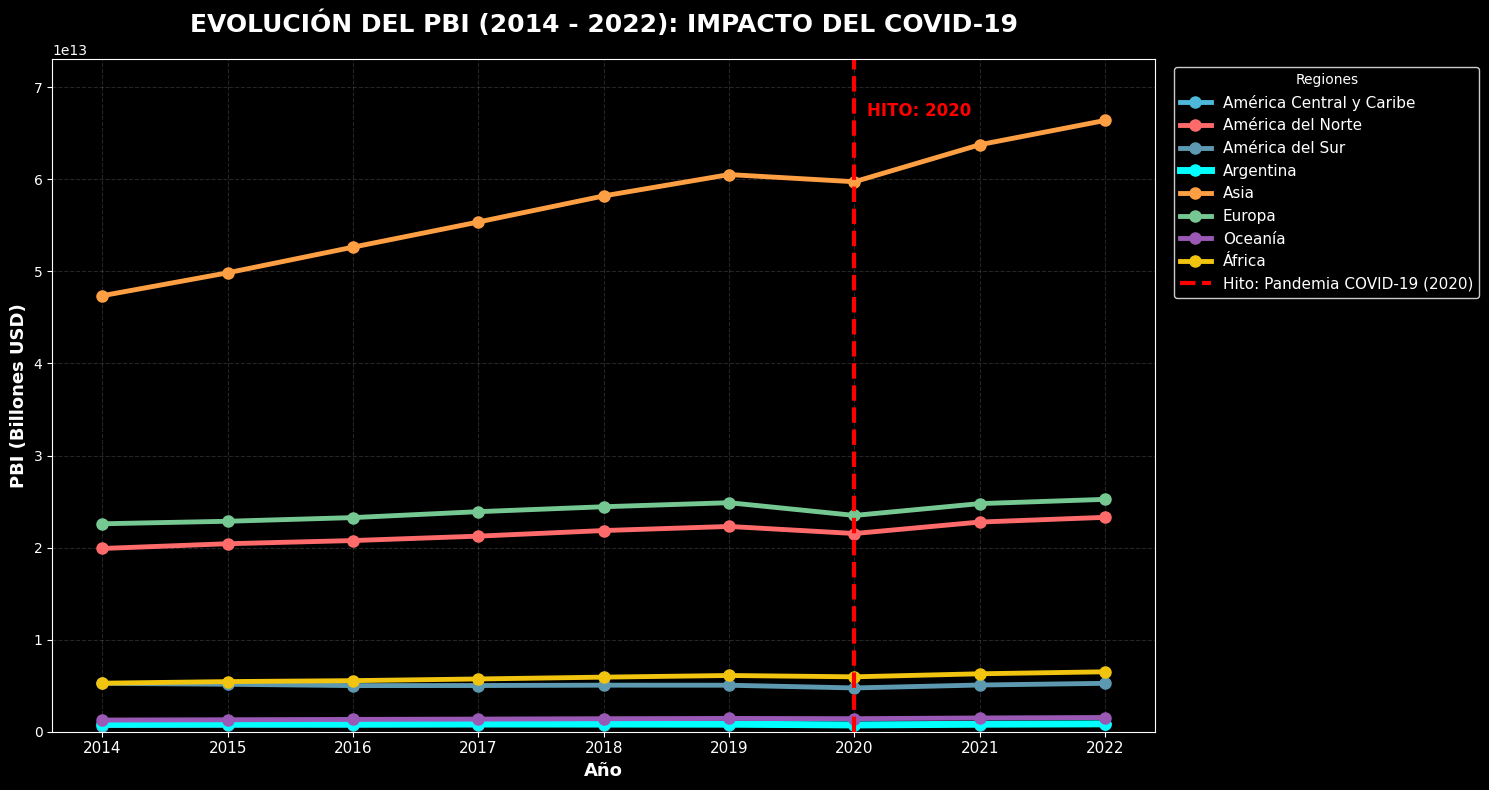

In [43]:
### EVOLUCIÓN DEL PBI: COVID-19 (2014-2022) ###

import matplotlib.pyplot as plt

# 1. Configurar estilo de contraste
plt.style.use('dark_background')

# 2. Definir la paleta con los COLORES FUERTES establecidos
paleta = {
    'América del Sur': '#5D99B0',       # Azul fuerte
    'América del Norte': '#FF6B6B',     # Salmón/Rojo fuerte
    'América Central y Caribe': '#4DB8D9', # Celeste profundo
    'Europa': '#76C893',               # Verde intenso
    'Asia': '#FF9F43',                 # Naranja vivo
    'África': '#F1C40F',               # Amarillo sólido
    'Oceanía': '#9B59B6',              # Púrpura oscuro
    'Argentina': '#00FFFF'             # Cyan brillante
}

# 3. Preparar los datos del período
df_periodo = df_covid_19.copy()
df_periodo['region'] = df_periodo['country'].apply(asignar_region)
evolucion_regiones = df_periodo[df_periodo['region'] != 'Otros'].groupby(['year', 'region'])['gdp'].sum().unstack()

# 4. Graficar
fig, ax = plt.subplots(figsize=(15, 8))
fig.patch.set_facecolor('black')
ax.set_facecolor('black')

for region in evolucion_regiones.columns:
    color = paleta.get(region, '#CCCCCC')
    linewidth = 5 if region == 'Argentina' else 3.5
    plt.plot(evolucion_regiones.index, evolucion_regiones[region], marker='o', markersize=8, color=color, linewidth=linewidth, label=region)

# 5. Hito Histórico: Pandemia COVID-19 (2020)
plt.axvline(x=2020, color='#FF0000', linestyle='--', linewidth=3, label='Hito: Pandemia COVID-19 (2020)')
plt.text(2020.1, evolucion_regiones.max().max(), 'HITO: 2020', color='#FF0000', fontsize=12, fontweight='bold', verticalalignment='bottom')

# 6. Configuración estética
max_region = evolucion_regiones.max().max()
plt.ylim(0, max_region * 1.1)

plt.title('EVOLUCIÓN DEL PBI (2014 - 2022): IMPACTO DEL COVID-19', fontsize=18, fontweight='bold', color='white', pad=20)
plt.xlabel('Año', fontsize=13, fontweight='bold')
plt.ylabel('PBI (Billones USD)', fontsize=13, fontweight='bold')

plt.xticks(range(2014, 2023), fontsize=11)
plt.grid(True, linestyle='--', alpha=0.15)
plt.legend(title="Regiones", bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=11, facecolor='black', edgecolor='white')

plt.tight_layout()
plt.show()

# Restaurar estilo
plt.style.use('default')

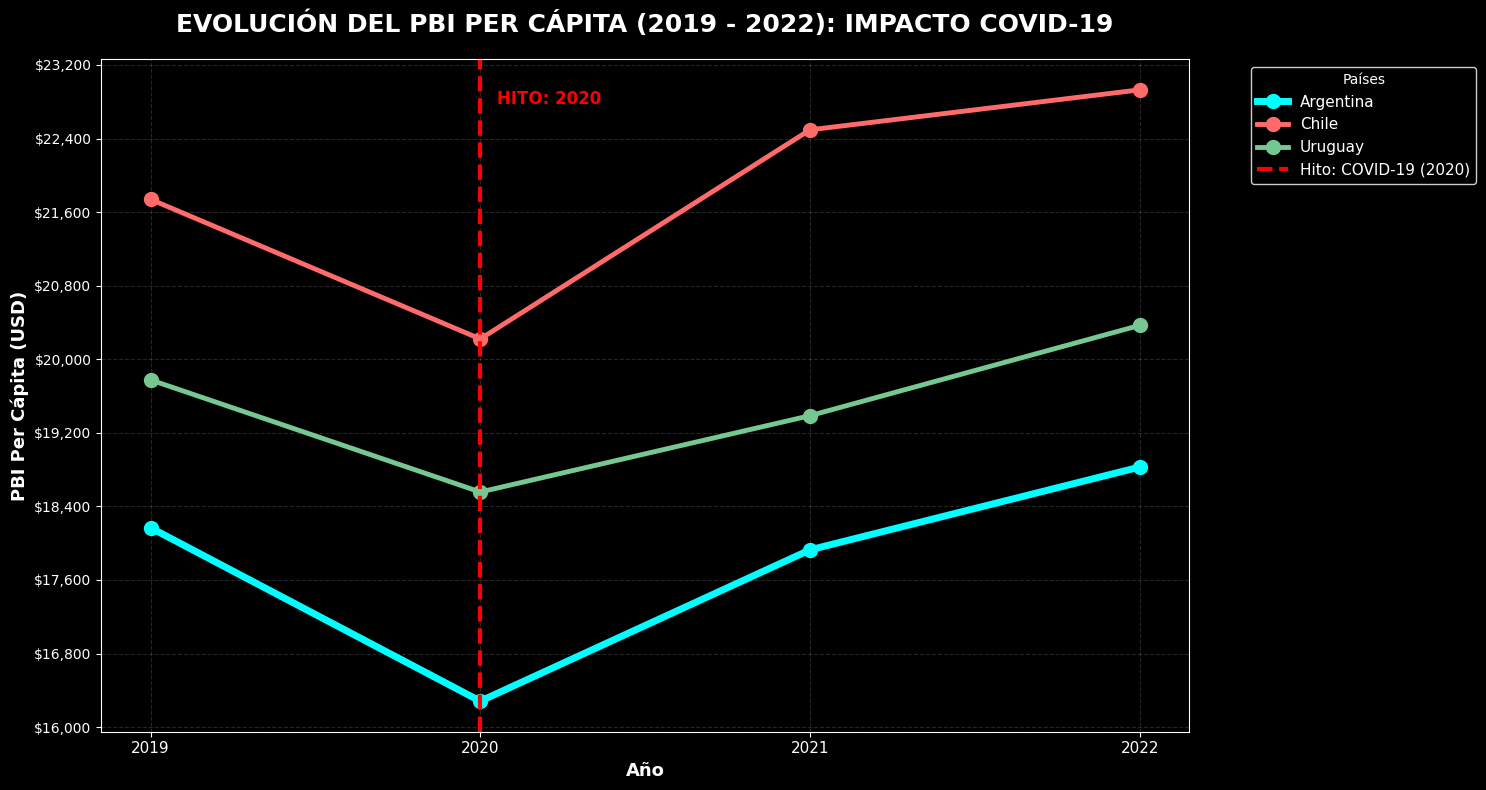

In [54]:
### COMPARATIVA PBI PER CÁPITA: ARGENTINA VS PAÍSES SELECCIONADOS (COVID-19) ###

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# 1. Configurar estilo de contraste
plt.style.use('dark_background')

# 2. Definir países y colores específicos
paises_seleccionados = ['Argentina', 'Chile', 'Uruguay']
colores_paises = {
    'Argentina': '#00FFFF',   # Cyan brillante
    'Chile': '#FF6B6B',       # Salmón vibrante
    'Uruguay': '#76C893'      # Verde intenso
}

# 3. Preparar los datos filtrando por el rango 2019-2022 (PBI PER CÁPITA)
df_comp = df[(df['country'].isin(paises_seleccionados)) & (df['year'] >= 2019) & (df['year'] <= 2022)]
evolucion_paises = df_comp.pivot_table(index='year', columns='country', values='gdp_per_capita')

# 4. Graficar
fig, ax = plt.subplots(figsize=(15, 8))
fig.patch.set_facecolor('black')
ax.set_facecolor('black')

for pais in evolucion_paises.columns:
    color = colores_paises.get(pais, '#CCCCCC')
    linewidth = 5 if pais == 'Argentina' else 3.5
    plt.plot(evolucion_paises.index, evolucion_paises[pais],
             marker='o', markersize=10, color=color, linewidth=linewidth, label=pais)

# 5. Hito Histórico: Pandemia COVID-19 (2020)
plt.axvline(x=2020, color='#FF0000', linestyle='--', linewidth=3, label='Hito: COVID-19 (2020)')
plt.text(2020.05, evolucion_paises.max().max(), 'HITO: 2020', color='#FF0000',
         fontsize=12, fontweight='bold', verticalalignment='top')

# 6. Configuración estética del Eje Y
ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=12))
# Formateador para mostrar en USD
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'${x:,.0f}'))

# 7. Configuración estética general
plt.title('EVOLUCIÓN DEL PBI PER CÁPITA (2019 - 2022): IMPACTO COVID-19',
          fontsize=18, fontweight='bold', color='white', pad=20)
plt.xlabel('Año', fontsize=13, fontweight='bold')
plt.ylabel('PBI Per Cápita (USD)', fontsize=13, fontweight='bold')

plt.xticks([2019, 2020, 2021, 2022], fontsize=11)
plt.grid(True, linestyle='--', alpha=0.15)

# Ajuste de leyenda
plt.legend(title="Países", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11, facecolor='black', edgecolor='white')

plt.tight_layout()
plt.show()

# Restaurar estilo
plt.style.use('default')